<a href="https://colab.research.google.com/github/Manikpreet/Customer-Segmentation-using-RFM-Analysis-and-K-Means-Clustering/blob/main/Online_Retail_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt
import numpy as np

In [ ]:
df=pd.read_csv('/content/online_retail_II.csv')

In [ ]:
df

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12.0,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12.0,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12.0,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48.0,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24.0,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
...,...,...,...,...,...,...,...,...
23467,491204,85078,SCANDINAVIAN 3 HEARTS NAPKIN RING,2.0,2009-12-10 13:59:00,0.65,14648.0,United Kingdom
23468,491204,21559,STRAWBERRY LUNCHBOX WITH CUTLERY,2.0,2009-12-10 13:59:00,2.55,14648.0,United Kingdom
23469,491204,22318,FIVE HEART HANGING DECORATION,1.0,2009-12-10 13:59:00,2.95,14648.0,United Kingdom
23470,491204,20914,SET/5 RED SPOTTY LID GLASS BOWLS,1.0,2009-12-10 13:59:00,2.95,14648.0,United Kingdom


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23472 entries, 0 to 23471
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Invoice      23472 non-null  object 
 1   StockCode    23472 non-null  object 
 2   Description  23424 non-null  object 
 3   Quantity     23471 non-null  float64
 4   InvoiceDate  23471 non-null  object 
 5   Price        23471 non-null  float64
 6   Customer ID  17312 non-null  float64
 7   Country      23471 non-null  object 
dtypes: float64(3), object(5)
memory usage: 1.4+ MB


In [ ]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12.0,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12.0,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12.0,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48.0,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24.0,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [ ]:
df.shape

(23472, 8)

In [ ]:
df.isnull()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...
1067366,False,False,False,False,False,False,False,False
1067367,False,False,False,False,False,False,False,False
1067368,False,False,False,False,False,False,False,False
1067369,False,False,False,False,False,False,False,False


In [ ]:
df[df.duplicated(subset=['Invoice','StockCode',	'Description',	'Quantity','InvoiceDate','Price','Customer ID','Country'])]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
371,489517,21912,VINTAGE SNAKES & LADDERS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
383,489517,22130,PARTY CONE CHRISTMAS DECORATION,6,2009-12-01 11:34:00,0.85,16329.0,United Kingdom
384,489517,22319,HAIRCLIPS FORTIES FABRIC ASSORTED,12,2009-12-01 11:34:00,0.65,16329.0,United Kingdom
385,489517,21913,VINTAGE SEASIDE JIGSAW PUZZLES,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
386,489517,21821,GLITTER STAR GARLAND WITH BELLS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
...,...,...,...,...,...,...,...,...
1067136,581538,22068,BLACK PIRATE TREASURE CHEST,1,2011-12-09 11:34:00,0.39,14446.0,United Kingdom
1067150,581538,23318,BOX OF 6 MINI VINTAGE CRACKERS,1,2011-12-09 11:34:00,2.49,14446.0,United Kingdom
1067153,581538,22992,REVOLVER WOODEN RULER,1,2011-12-09 11:34:00,1.95,14446.0,United Kingdom
1067160,581538,22694,WICKER STAR,1,2011-12-09 11:34:00,2.10,14446.0,United Kingdom


In [ ]:
df = df[~df.duplicated()]
df.dropna(subset=['Customer ID'], inplace=True)

df['Customer ID'] = df['Customer ID'].astype(int)
df = df[df['Customer ID'] > 0]
# Remove rows where Quantity or Price are negative (returns/cancellations or invalid data)
df = df[df['Quantity'] > 0]
df = df[df['Price'] > 0]

# Convert InvoiceDate to datetime objects
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

print("\nCleaned DataFrame Head:")
print(df.head())
print(f"DataFrame shape after cleaning: {df.shape}")


Cleaned DataFrame Head:
  Invoice StockCode                          Description  Quantity  \
0  489434     85048  15CM CHRISTMAS GLASS BALL 20 LIGHTS        12   
1  489434    79323P                   PINK CHERRY LIGHTS        12   
2  489434    79323W                  WHITE CHERRY LIGHTS        12   
3  489434     22041         RECORD FRAME 7" SINGLE SIZE         48   
4  489434     21232       STRAWBERRY CERAMIC TRINKET BOX        24   

          InvoiceDate  Price  Customer ID         Country  
0 2009-12-01 07:45:00   6.95        13085  United Kingdom  
1 2009-12-01 07:45:00   6.75        13085  United Kingdom  
2 2009-12-01 07:45:00   6.75        13085  United Kingdom  
3 2009-12-01 07:45:00   2.10        13085  United Kingdom  
4 2009-12-01 07:45:00   1.25        13085  United Kingdom  
DataFrame shape after cleaning: (779425, 8)


In [ ]:
df['InvoiceDate'].dt.time

,InvoiceDate
0,07:45:00
1,07:45:00
2,07:45:00
3,07:45:00
4,07:45:00
...,...
1067366,12:50:00
1067367,12:50:00
1067368,12:50:00
1067369,12:50:00


In [ ]:
df['InvoiceDate']

,InvoiceDate
0,2009-12-01 07:45:00
1,2009-12-01 07:45:00
2,2009-12-01 07:45:00
3,2009-12-01 07:45:00
4,2009-12-01 07:45:00
...,...
1067366,2011-12-09 12:50:00
1067367,2011-12-09 12:50:00
1067368,2011-12-09 12:50:00
1067369,2011-12-09 12:50:00


In [ ]:
df['TotalPrice'] = df['Quantity'] * df['Price']
df.groupby('Customer ID')['TotalPrice'].sum()

,TotalPrice
Customer ID,
12346,77556.46
12347,4921.53
12348,2019.40
12349,4428.69
12350,334.40
...,...
18283,2664.90
18284,461.68
18285,427.00



--- Step 3: Calculating RFM Metrics ---
Snapshot Date for Recency calculation: 2011-12-10 12:50:00

RFM DataFrame Head:
   Customer ID  Recency  Frequency  Monetary
0        12346      326         12  77556.46
1        12347        2          8   4921.53
2        12348       75          5   2019.40
3        12349       19          4   4428.69
4        12350      310          1    334.40

RFM DataFrame Description:
        Customer ID      Recency    Frequency       Monetary
count   5878.000000  5878.000000  5878.000000    5878.000000
mean   15315.313542   201.331916     6.289384    2955.904095
std     1715.572666   209.338707    13.009406   14440.852688
min    12346.000000     1.000000     1.000000       2.950000
25%    13833.250000    26.000000     1.000000     342.280000
50%    15314.500000    96.000000     3.000000     867.740000
75%    16797.750000   380.000000     7.000000    2248.305000
max    18287.000000   739.000000   398.000000  580987.040000


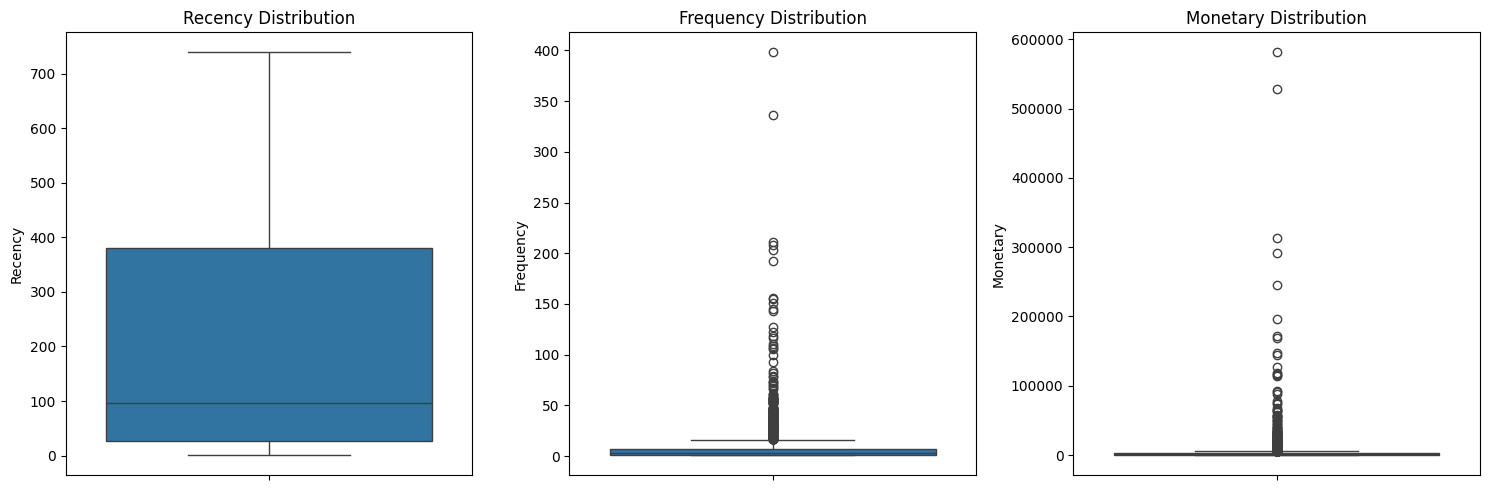


RFM Log-Transformed DataFrame Head:
    Recency  Frequency   Monetary
0  5.789960   2.564949  11.258774
1  1.098612   2.197225   8.501578
2  4.330733   1.791759   7.611051
3  2.995732   1.609438   8.396085
4  5.739793   0.693147   5.815324


In [ ]:
# --- Step 3: Calculate RFM Metrics ---
print("\n--- Step 3: Calculating RFM Metrics ---")

# Calculate TotalPrice for each transaction item
df['TotalPrice'] = df['Quantity'] * df['Price']

# Define a snapshot date for Recency calculation (usually the day after the last invoice date)
snapshot_date = df['InvoiceDate'].max() + dt.timedelta(days=1)
print(f"Snapshot Date for Recency calculation: {snapshot_date}")

# Group by CustomerID to calculate RFM values
rfm_df = df.groupby('Customer ID').agg({
    'InvoiceDate': lambda date: (snapshot_date - date.max()).days, # Days since last purchase
    'Invoice': 'nunique',                                        # Number of unique invoices
    'TotalPrice': 'sum'                                          # Total money spent
}).reset_index()

# Rename columns to Recency, Frequency, and Monetary
rfm_df.columns = ['Customer ID', 'Recency', 'Frequency', 'Monetary']

print("\nRFM DataFrame Head:")
print(rfm_df.head())
print("\nRFM DataFrame Description:")
print(rfm_df.describe())

# Check for outliers in RFM features (optional, but good practice)
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.boxplot(y=rfm_df['Recency'])
plt.title('Recency Distribution')

plt.subplot(1, 3, 2)
sns.boxplot(y=rfm_df['Frequency'])
plt.title('Frequency Distribution')

plt.subplot(1, 3, 3)
sns.boxplot(y=rfm_df['Monetary'])
plt.title('Monetary Distribution')

plt.tight_layout()
plt.show()

# Apply Log transformation to handle skewness and large ranges for K-means
# Add a small constant to avoid Log(0) if any RFM value is 0 (though not expected for our calculations)
rfm_log = rfm_df[['Recency', 'Frequency', 'Monetary']].apply(lambda x: x + 1).apply(np.log)
print("\nRFM Log-Transformed DataFrame Head:")
print(rfm_log.head())

In [ ]:
# --- Step 4: Scale the RFM Features ---
print("\n--- Step 4: Scaling RFM Features ---")
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log)
rfm_scaled_df = pd.DataFrame(rfm_scaled, columns=['Recency_Scaled', 'Frequency_Scaled', 'Monetary_Scaled'])
print("\nRFM Scaled DataFrame Head:")
print(rfm_scaled_df.head())


--- Step 4: Scaling RFM Features ---

RFM Scaled DataFrame Head:
   Recency_Scaled  Frequency_Scaled  Monetary_Scaled
0        0.856701          1.254496         3.206219
1       -2.151979          0.800166         1.215993
2       -0.079138          0.299207         0.573185
3       -0.935308          0.073946         1.139846
4        0.824527         -1.058146        -0.723024


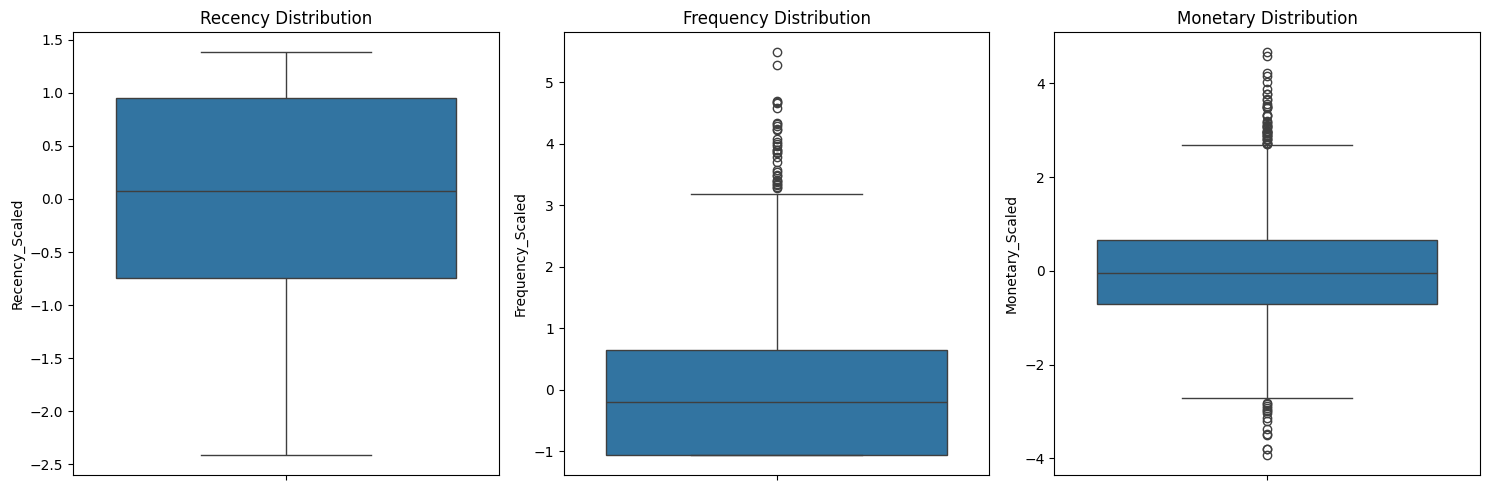

In [ ]:
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
sns.boxplot(y=rfm_scaled_df['Recency_Scaled'])
plt.title('Recency Distribution')

plt.subplot(1, 3, 2)
sns.boxplot(y=rfm_scaled_df['Frequency_Scaled'])
plt.title('Frequency Distribution')

plt.subplot(1, 3, 3)
sns.boxplot(y=rfm_scaled_df['Monetary_Scaled'])
plt.title('Monetary Distribution')

plt.tight_layout()
plt.show()


--- Step 5: Determining Optimal Number of Clusters (Elbow Method) ---


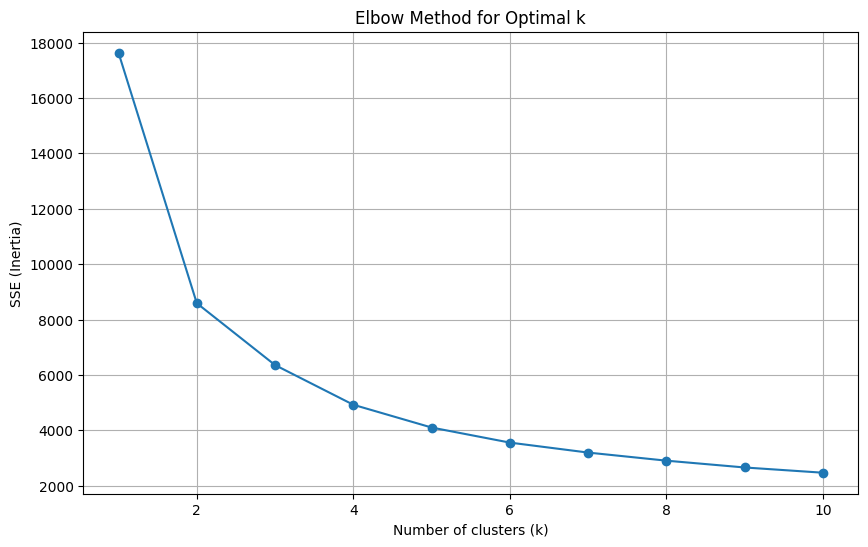

In [ ]:
# --- Step 5: Determine Optimal Number of Clusters (Elbow Method) ---
print("\n--- Step 5: Determining Optimal Number of Clusters (Elbow Method) ---")
sse = {}
for k in range(1, 11): # Test k from 1 to 10
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10) # n_init for robust results
    kmeans.fit(rfm_scaled_df)
    sse[k] = kmeans.inertia_ # Sum of squared distances of samples to their closest cluster center

plt.figure(figsize=(10, 6))
plt.plot(list(sse.keys()), list(sse.values()), marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("SSE (Inertia)")
plt.title("Elbow Method for Optimal k")
plt.grid(True)
plt.show()


--- Step 6: Applying K-Means Clustering with k=4 ---

RFM DataFrame with Clusters Head:
   Customer ID  Recency  Frequency  Monetary  Cluster
0        12346      326         12  77556.46        2
1        12347        2          8   4921.53        2
2        12348       75          5   2019.40        3
3        12349       19          4   4428.69        1
4        12350      310          1    334.40        0

--- Step 7: Analyzing and Interpreting Clusters ---

Cluster Analysis (Mean RFM Values and Customer Count per Cluster):
         Recency_Mean  Frequency_Mean  Monetary_Mean  Count
Cluster                                                    
0              394.95            1.38         317.08   1973
1               28.30            3.05         857.49   1250
2               27.71           19.28       10731.16   1196
3              230.07            5.06        1948.50   1459


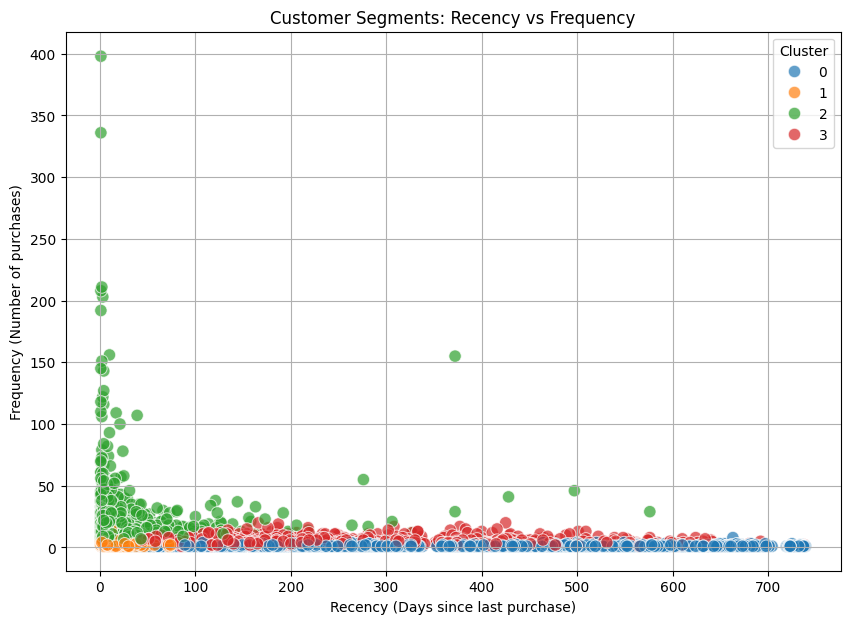

In [ ]:
optimal_k = 4
print(f"\n--- Step 6: Applying K-Means Clustering with k={optimal_k} ---")
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
rfm_df['Cluster'] = kmeans.fit_predict(rfm_scaled_df)

print("\nRFM DataFrame with Clusters Head:")
print(rfm_df.head())

# --- Step 7: Analyze and Interpret Clusters ---
print("\n--- Step 7: Analyzing and Interpreting Clusters ---")
cluster_analysis = rfm_df.groupby('Cluster').agg(
    Recency_Mean=('Recency', 'mean'),
    Frequency_Mean=('Frequency', 'mean'),
    Monetary_Mean=('Monetary', 'mean'),
    Count=('Customer ID', 'count')
).round(2)

print("\nCluster Analysis (Mean RFM Values and Customer Count per Cluster):")
print(cluster_analysis)

# Optional: Visualize clusters (e.g., using a pair plot or 3D scatter plot)
# For 3D visualization, you might need a custom function or plotly
# For simplicity, let's visualize Recency vs Frequency with cluster colors
plt.figure(figsize=(10, 7))
sns.scatterplot(x='Recency', y='Frequency', hue='Cluster', data=rfm_df, palette='tab10', s=80, alpha=0.7)
plt.title('Customer Segments: Recency vs Frequency')
plt.xlabel('Recency (Days since last purchase)')
plt.ylabel('Frequency (Number of purchases)')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()

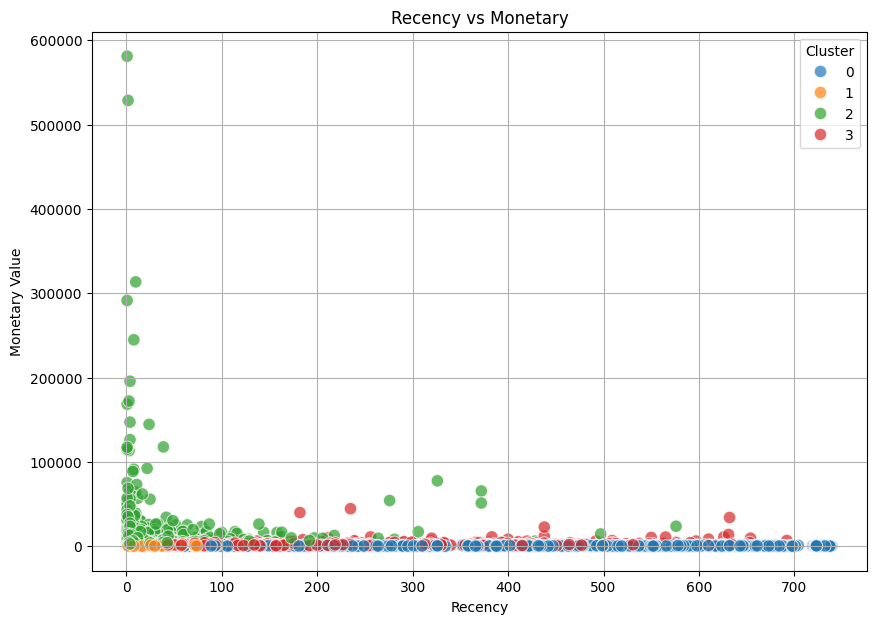

In [ ]:
plt.figure(figsize=(10,7))
sns.scatterplot(x='Recency', y='Monetary', hue='Cluster', data=rfm_df, palette='tab10', s=80, alpha=0.7)
plt.xlabel('Recency')
plt.ylabel('Monetary Value')
plt.title('Recency vs Monetary')
plt.legend(title='Cluster')
plt.grid()
plt.show()


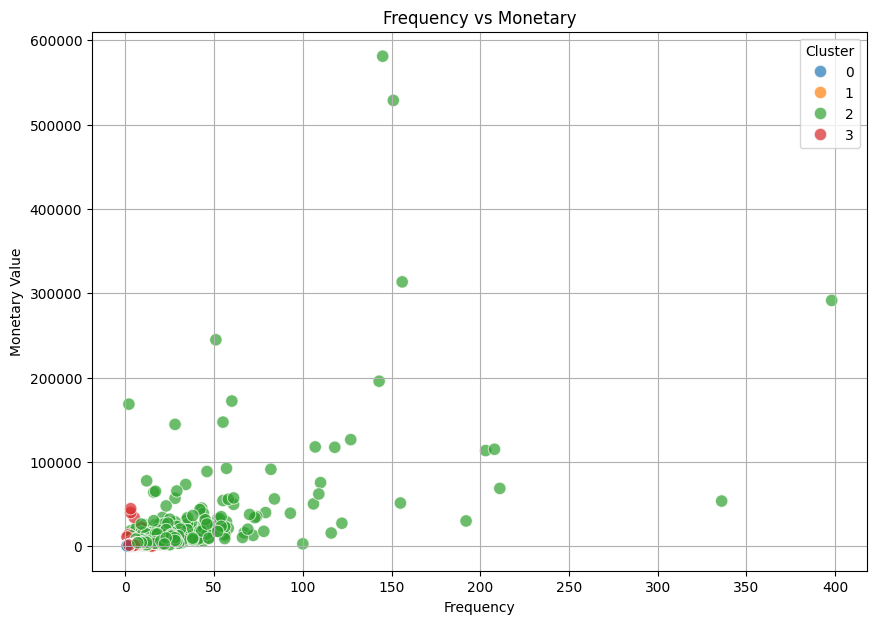

In [ ]:
plt.figure(figsize=(10,7))
sns.scatterplot(x='Frequency', y='Monetary', hue='Cluster', data=rfm_df, palette='tab10', s=80, alpha=0.7)
plt.xlabel('Frequency')
plt.ylabel('Monetary Value')
plt.title('Frequency vs Monetary')
plt.legend(title='Cluster')
plt.grid()
plt.show()

In [ ]:
rfm_df['Cluster'].value_counts(normalize=True)


,proportion
Cluster,
0,0.335658
3,0.248214
1,0.212657
2,0.203471


In [ ]:
rfm_df.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean()


,Recency,Frequency,Monetary
Cluster,,,
0,394.946275,1.377598,317.081501
1,28.304800,3.053600,857.491434
2,27.711538,19.275920,10731.162991
3,230.072653,5.058259,1948.503933


In [ ]:
cluster_labels = {
    0: 'Champions',
    1: 'Loyal Customers',
    2: 'At Risk',
    3: 'Lost Customers'
}

rfm_df['Segment'] = rfm_df['Cluster'].map(cluster_labels)


In [ ]:
rfm_df[['Customer ID', 'Segment']].head()


,Customer ID,Segment
0,12346,At Risk
1,12347,At Risk
2,12348,Lost Customers
3,12349,Loyal Customers
4,12350,Champions


In [ ]:
rfm_df.to_csv('Customer_Segmentation_RFM.csv', index=False)